## Open notebook in:
| Colab                                  Gradient                                                                                                                                         |
|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nicolepcx/Transformers-in-Action/blob/main/CH07/text_classification_financial_phrasebank.ipynb)                                              | [!            

# About this notebook

This notebook demonstrates end-to-end fine-tuning of **ModernBERT** on the *Financial PhraseBank* dataset for sentiment classification. It covers:

* **Dataset preparation:** Loading, merging, stratified splitting, and balancing the dataset with undersampling of the Neutral class.
* **Visualization:** Helper functions to plot label distributions before and after balancing, as well as a confusion matrix for evaluation.
* **Model setup:** Initializing ModernBERT with sentiment labels and configuring tokenizer, collator, and metrics.
* **Training and evaluation:** Using Hugging Face `Trainer` with accuracy, precision, recall, and F1 metrics, saving the best model, and reporting test performance.
* **Results analysis:** Confusion matrix visualization with both raw counts and normalized values.

The workflow provides a reproducible pipeline for financial sentiment analysis, from data preprocessing to fine-tuning and model evaluation.


# Install requirements

In [ ]:
!pip install -q accelerate datasets peft bitsandbytes trl evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00


# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, f1_score


# Plotting helper

In [ ]:
def plot_dataset_distribution(datasets, dataset_names, label_map=None):
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)

    if n == 1:
        axes = [axes]

    for dataset, dataset_name, ax in zip(datasets, dataset_names, axes):
        # Convert the dataset to a DataFrame if it's not already
        if not isinstance(dataset, pd.DataFrame):
            dataset = dataset.to_pandas()

        label_counts = dataset["label"].map(label_map).value_counts()
        label_names = label_counts.index.tolist()

        # plot the label distribution
        colors = ['#58A3B3', '#f9f7ef', 'darkgrey', 'gray', '#ddebee', 'gainsboro']
        bars = ax.bar(range(len(label_counts.values)), list(label_counts.values), color=colors)
        ax.set_title(f"{dataset_name} ({len(dataset)} samples)")
        ax.set_xlabel("Label")
        ax.set_ylabel("Count")
        ax.set_xticks(range(len(label_counts.values)))
        ax.set_xticklabels(label_names)

        # Display counts above each bar
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f"{height}",
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center", va="bottom")

    plt.show()

# Load and merge Dataset

In [ ]:

raw = load_dataset("FinanceMTEB/financial_phrasebank")
# Merge original train and test to re-split as you prefer
full_df = pd.concat([
    pd.DataFrame(raw["train"]),
    pd.DataFrame(raw["test"])
], ignore_index=True)

# Keep only what we need
full_df = full_df[["text", "label"]].dropna().reset_index(drop=True)


# Stratified split with a small test set

In [ ]:
TEST_SIZE = 0.10          # 10 percent for test
VAL_SIZE = 0.10           # 10 percent for validation, taken from the train pool

train_pool_df, test_df = train_test_split(
    full_df,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=full_df["label"]
)

train_df, val_df = train_test_split(
    train_pool_df,
    test_size=VAL_SIZE,
    random_state=42,
    stratify=train_pool_df["label"]
)

# Undersample the Neutral class on the training set

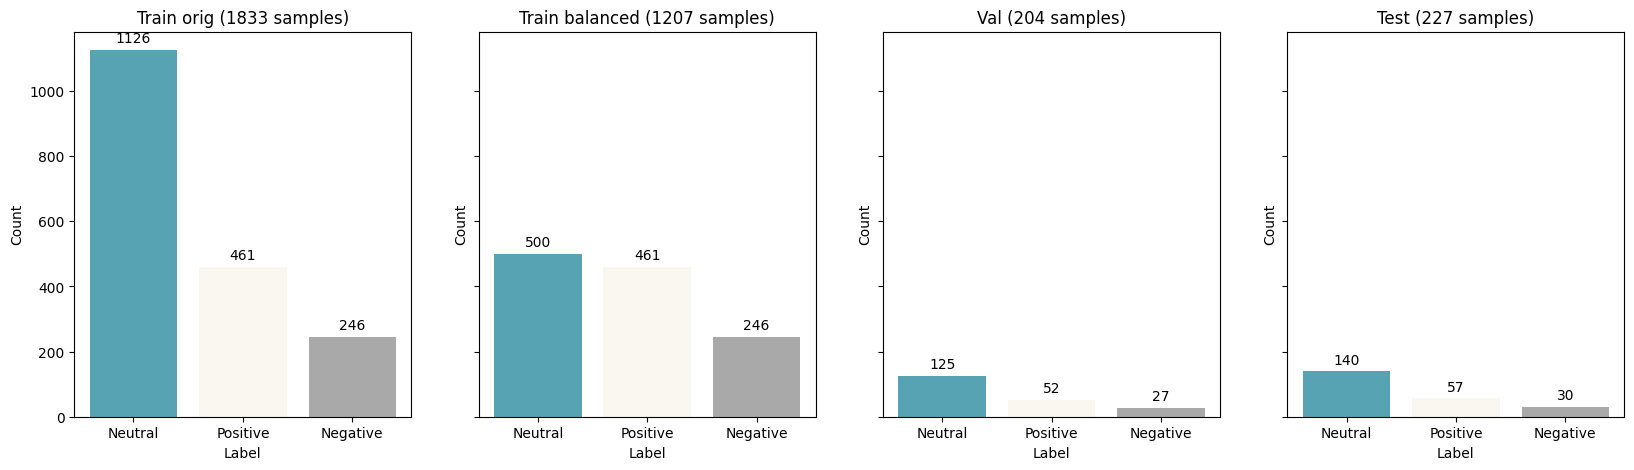

In [ ]:
NEUTRAL_CAP = 500

neg_df = train_df[train_df["label"] == 0]
neu_df = train_df[train_df["label"] == 1]
pos_df = train_df[train_df["label"] == 2]

if len(neu_df) > NEUTRAL_CAP:
    neu_df = neu_df.sample(n=NEUTRAL_CAP, random_state=42)

balanced_train_df = pd.concat([neg_df, pos_df, neu_df], ignore_index=True)
balanced_train_df = balanced_train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# Optional: visualize before and after
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
plot_dataset_distribution([train_df, balanced_train_df, val_df, test_df],
                           ["Train orig", "Train balanced", "Val", "Test"],
                           label_map=label_map)

# Convert back to HF Datasets

In [ ]:
def to_hf_dataset(df: pd.DataFrame) -> Dataset:
    # Cast to pyarrow types expected by HF
    return Dataset.from_pandas(df, preserve_index=False)

dataset = DatasetDict({
    "train": to_hf_dataset(balanced_train_df),
    "validation": to_hf_dataset(val_df),
    "test": to_hf_dataset(test_df),
})


# Model and tokenizer

In [ ]:
model_name = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    device_map="auto",
    trust_remote_code=True,
)


# Tokenization

In [ ]:
max_length = 128
def preprocess(batch):
    toks = tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length
    )
    toks["labels"] = batch["label"]
    return toks

encoded = dataset.map(preprocess, batched=True, remove_columns=dataset["train"].column_names)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# Metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


# Train Model

In [ ]:
training_args = TrainingArguments(
    output_dir="./results_modernbert_cls",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=3e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    tokenizer=tokenizer,
)

trainer.train()
print(trainer.evaluate(encoded["test"]))


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

...

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nicolepcx to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W0910 05:23:22.674000 6597 torch/_inductor/utils.py:1436] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.541108,0.882353,0.824450,0.906051,0.851977
2,0.416100,0.322533,0.916667,0.880663,0.933757,0.902985
3,0.056800,0.272693,0.931373,0.894512,0.941757,0.915265


{'eval_loss': 0.19480954110622406, 'eval_accuracy': 0.9559471365638766, 'eval_precision': 0.9393584289583101, 'eval_recall': 0.9430659983291562, 'eval_f1': 0.9407289563319668, 'eval_runtime': 1.2164, 'eval_samples_per_second': 186.614, 'eval_steps_per_second': 12.331, 'epoch': 3.0}


# Plot Confusion Matrix

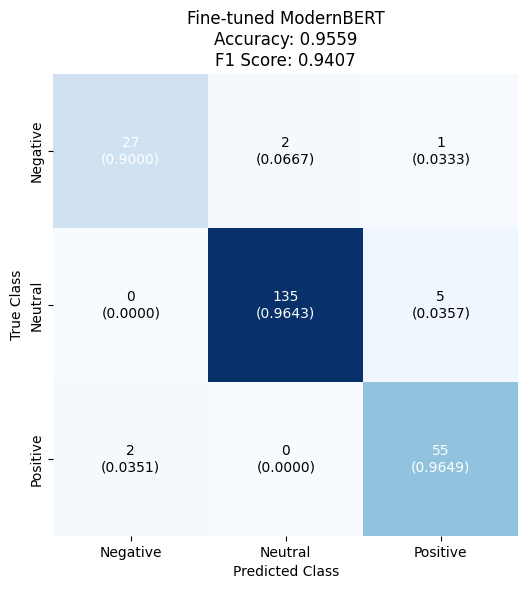

In [ ]:

def plot_confusion_matrix(y_true, y_pred, labels, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # row-normalized

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    plt.figure(figsize=(6, 6))
    sns.heatmap(
        cm, annot=False, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, cbar=False
    )

    # Write values with normalized score in parentheses
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            norm_val = cm_norm[i, j]
            plt.text(j + 0.5, i + 0.5,
                     f"{value}\n({norm_val:.4f})",
                     ha="center", va="center",
                     color="white" if norm_val > 0.5 else "black")

    plt.title(f"Fine-tuned {model_name}\nAccuracy: {acc:.4f}\nF1 Score: {f1:.4f}")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()


preds = trainer.predict(encoded["test"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=-1)

plot_confusion_matrix(
    y_true, y_pred, labels=["Negative", "Neutral", "Positive"], model_name="ModernBERT"
)
